In [6]:
import requests


def search_jina(query: str, token: str) -> dict:
    url = f"https://api.jina.ai/search"
    headers = {
        "Authorization": f"Bearer {token}",
        "Content-Type": "application/json",
    }
    params = {"q": query}

    response = requests.get(url, headers=headers, params=params)
    response.raise_for_status()

    return response.json()


# Example usage
result = search_jina(
    "latest AMD news",
    "jina_ae8efb2453b442159f43c8769887c3e1advnNaChSbCXLG4QSv-bj_T83oQ1",
)
print(result)


HTTPError: 404 Client Error: Not Found for url: https://api.jina.ai/search?q=latest+AMD+news

/var/folders/b8/c5k3kkjj1kzc5x7x9sj0xp480000gn/T/ipykernel_23324/1317431925.py:49: RuntimeWarning: invalid value encountered in sqrt
  ucl = np.sqrt(n1 * (n2 * f.ppf(1 - alpha, n1, n2)) / (n2 - n1))


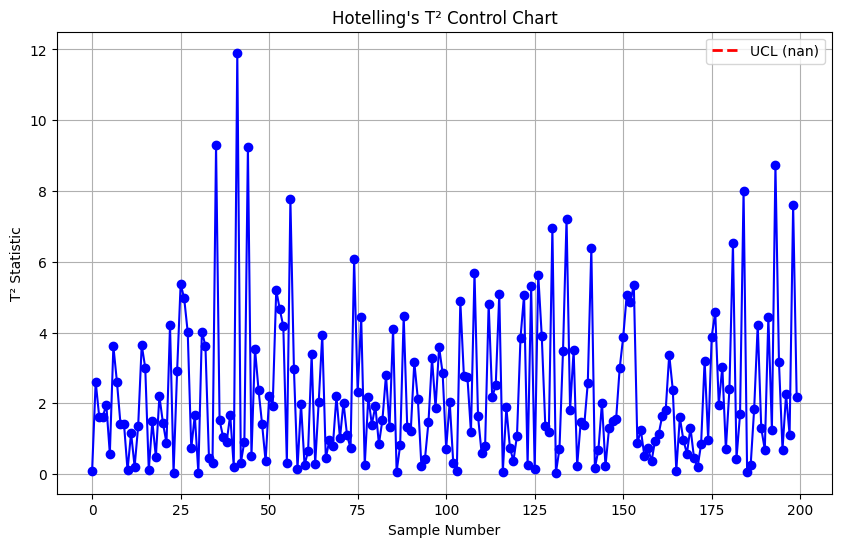

Out of control points detected at indices: []


In [12]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Simulation parameters
n_samples = 100
n_features = 5
mean = np.zeros(n_features)
cov = np.eye(n_features)  # Identity covariance matrix

# Generate in-control data
data_in = np.random.multivariate_normal(mean, cov, n_samples)

# Simulate an out-of-control shift (e.g., mean of first feature increases by 1.5)
out_of_control_start = 80
mean_out = np.zeros(n_features)
mean_out[0] = 1.5  # Shift the mean of the first feature

data_out = []
for i in range(n_samples):
    if i >= out_of_control_start:
        data_out.append(np.random.multivariate_normal(mean_out, cov))
    else:
        data_out.append(np.random.multivariate_normal(mean, cov))

# Combine data
data = np.concatenate((np.array(data_in), np.array(data_out)))

# Apply PCA for dimensionality reduction (if needed)
pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
principal_components = pca.fit_transform(data)

# Calculate Hotelling's T² statistic
t_squared = []
for i in range(len(principal_components)):
    t_sq = np.dot(principal_components[i], principal_components[i])
    t_squared.append(t_sq)

# Determine control limits (UCL) using the 99th percentile of the F-distribution
n1 = len(principal_components)
n2 = n_features - len(pca.components_)
alpha = 0.01  # Significance level

from scipy.stats import f

ucl = np.sqrt(n1 * (n2 * f.ppf(1 - alpha, n1, n2)) / (n2 - n1))

# Create control chart
plt.figure(figsize=(10, 6))
plt.plot(t_squared, marker="o", linestyle="-", color="blue")
plt.axhline(
    y=ucl, color="red", linestyle="--", linewidth=2, label=f"UCL ({ucl:.4f})"
)
plt.title("Hotelling's T² Control Chart")
plt.xlabel("Sample Number")
plt.ylabel("T² Statistic")
plt.legend()
plt.grid(True)
plt.show()

# Identify out-of-control points
out_of_control_points = [i for i, val in enumerate(t_squared) if val > ucl]

print(f"Out of control points detected at indices: {out_of_control_points}")
